In [24]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
import matplotlib.pyplot as plt
import mpl_scatter_density




# data = np.load("../../../_recordings/Z_7_all_measurements_2024-05-07--20-58-09/archive.npz")

data = np.load("../../../_recordings/Z_7_all_measurements_2024-05-10--11-50-15/archive.npz")

results = {}

for experiment in data.keys():
    experiment_parameters = data[experiment]["reboot_seed"]["experiment_parameters"][0]
    shape = experiment_parameters["shape"]

    if shape[0] in results:
        results[shape[0]].append(data[experiment])
    else:
        results[shape[0]] = [data[experiment]]

z_order = 7
roots_of_unity = np.array([[np.cos(2 * np.pi * i / z_order),
                                np.sin(2 * np.pi * i / z_order)] for i in range(z_order)])



time_series = [] 
tin_data = []
lattice_sizes = []

result_keys = list(results.keys())
result_keys.sort()

pp_correlators = {}


for shape in result_keys:
    results[shape].sort(key=lambda x: x["reboot_seed"]["experiment_parameters"]["beta"])
    results[shape] = np.array(results[shape])

    rec_shape = results[shape]["ploop_corr_recordings"]["polyakov_loops"].shape

    _,_,number_rec, x_dim, y_dim, z_dim = rec_shape


    loops = results[shape]["ploop_corr_recordings"]["polyakov_loops"]
    loops = roots_of_unity[loops]

    # Tin Data
    temp = loops.sum(axis=(3,4,5))
    tin_snapshot = np.linalg.norm(temp, axis=-1)  
    tin_snapshot = tin_snapshot.sum(axis=(1,2))/(number_rec*x_dim*y_dim*z_dim)
    tin_data.append(tin_snapshot)

    # Time series
    time_serie = loops.sum(axis=(3,4,5)).squeeze(axis=1)/(x_dim*y_dim*z_dim)
    time_series.append(time_serie)

    betas = results[shape]["reboot_seed"]["experiment_parameters"]["beta"].squeeze()

    lattice_sizes.append(x_dim)

    pp_correlators[x_dim] = results[shape]["ploop_corr_recordings"]["pp_correlators"]

 

# save the pp correlators
np.savez("../../../temp/pp_correlators", pp_correlators=pp_correlators)
    

# save the time series
time_series = np.array(time_series)
tin_data = np.array(tin_data)



np.savez("../../../temp/z_7", time_series=time_series, tin_data=tin_data, betas=betas, lattice_sizes=lattice_sizes)  

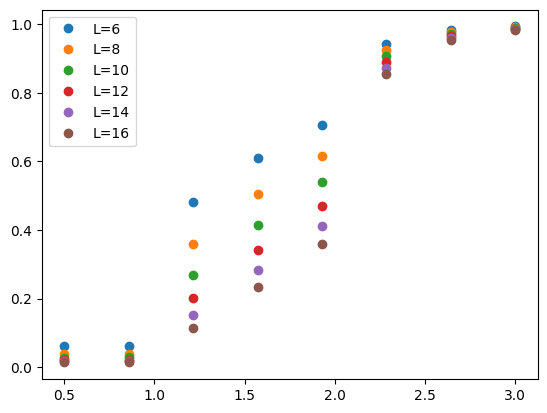

In [25]:
data_transfer = np.load("../../../temp/z_7.npz")

tin_data = data_transfer["tin_data"]
betas = data_transfer["betas"]
lattice_sizes = data_transfer["lattice_sizes"]

fig, ax = plt.subplots()

for i in range(len(tin_data)):
    ax.plot(betas, tin_data[i],'o', label=f"L={lattice_sizes[i]}")

plt.legend()
plt.show()



(6, 8, 9000, 2)
6


/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/landa/Documents/GitHub/crunchy/myenv/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


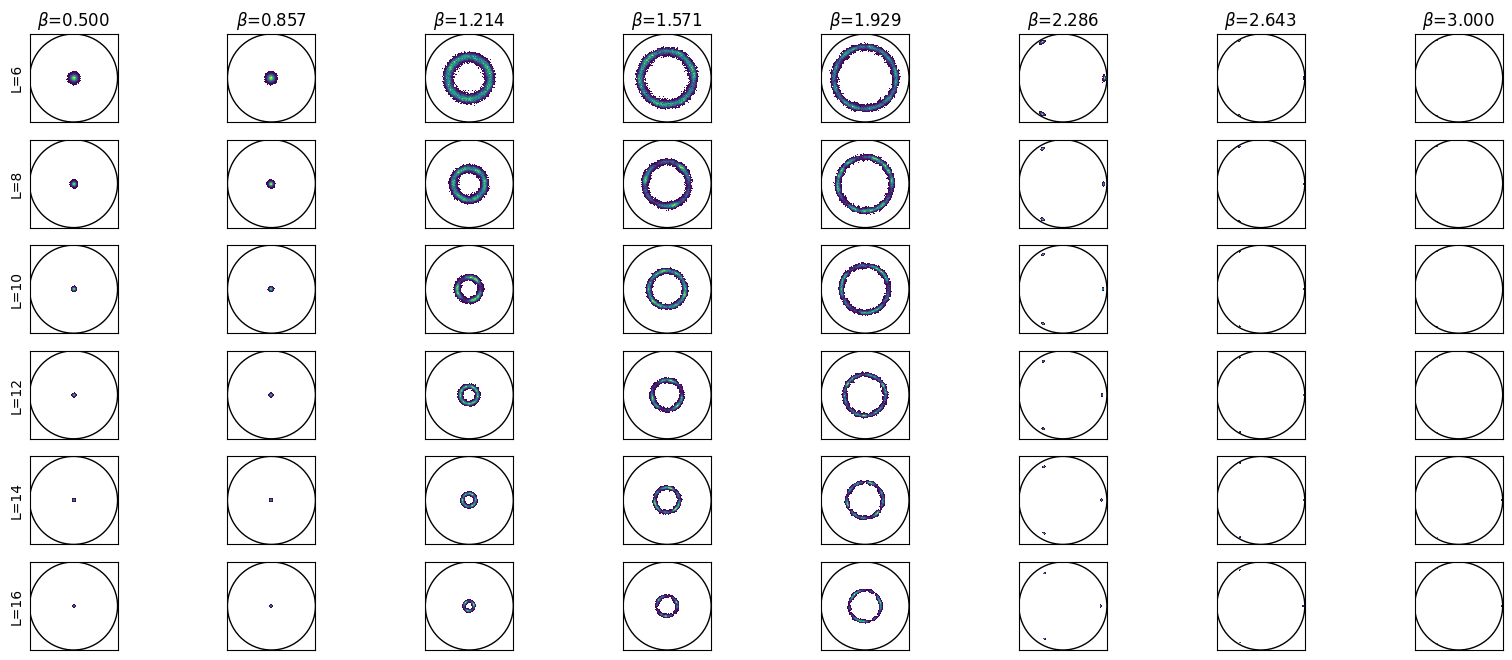

In [26]:
data_transfer = np.load("../../../temp/z_7.npz")

time_series = data_transfer["time_series"]

time_series_cutoff = 1000

time_series = time_series[:, :,time_series_cutoff:,...]

print(time_series.shape)


num_lattice_sizes = time_series.shape[0]
print(num_lattice_sizes)

# print(betas)

rows = num_lattice_sizes
columns = len(time_series[0])


fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(rows, columns)

axes = []

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

for i in range(rows):
    for j in range(columns):
        time_serie = time_series[i][j]
        time_serie_rotated = time_serie.copy()
        rotation_matrix = np.array([[np.cos(2 * np.pi / 3), -np.sin(2 * np.pi / 3)], [
                                    np.sin(2 * np.pi / 3), np.cos(2 * np.pi / 3)]])

        time_serie_rotated = np.dot(time_serie, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        time_serie_rotated = np.dot(time_serie_rotated, rotation_matrix)
        time_serie = np.concatenate([time_serie, time_serie_rotated])

        x = time_serie[:, 0]
        y = time_serie[:, 1]

        radius = 1

        axes.append(fig.add_subplot(
            gs[i, j], projection='scatter_density'))

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].scatter_density(x, y, cmap=white_viridis, dpi=200)

        axes[-1].set_xlim(-radius, radius)
        axes[-1].set_ylim(-radius, radius)

        axes[-1].set_aspect('equal', 'box')
        axes[-1].set_xticks([])
        axes[-1].set_yticks([])
        # axes[-1].set_title(f"{index}")
        circle = plt.Circle((0, 0), 1, color='black', fill=False)
        axes[-1].add_artist(circle)


for i in range(columns):
    axes[i].set_title(r"$\beta$={:.3f}".format(
        betas[i]))

# Add title to rows
for i in range(rows):
    axes[i*columns].set_ylabel(f"L={lattice_sizes[i]}")

plt.show()


(10000, 11, 2)
(10000, 11, 2)
(10000,)


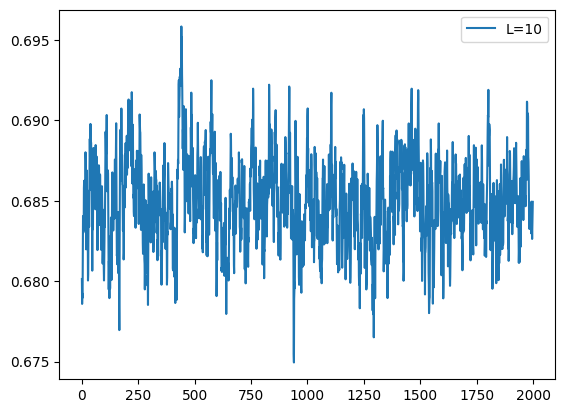

In [40]:
%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt

data = np.load("../../../temp/pp_correlators.npz", allow_pickle=True)

pp_correlators = data["pp_correlators"].item()

lattice = 3

fig = plt.figure()

for key in pp_correlators.keys():
    if key != 10:
        continue

    pp_correlator = pp_correlators[key][lattice,:,...].squeeze(axis=0)

    print(pp_correlator.shape)



    lattice_size = 2
    time_series = pp_correlator

    print(time_series.shape)
    time_series = time_series[:,lattice_size,0]
    print(time_series.shape)

    

    time_series = time_series[2000:4000]

    xs = np.arange(len(time_series))

    plt.plot(xs, time_series, '-', label=f"L={key}")



    pp_correlator = pp_correlator.mean(axis=0)

    

    cutoff = 1

    pp_correlator = pp_correlator[cutoff:-cutoff]

   

    # real_part = pp_correlator[:,0]

    # Ls = np.arange(len(real_part))

    # max_L = np.max(Ls)
    # Ls = Ls / max_L

    # plt.plot(Ls, real_part, '-o' , label=f"L={key}")

plt.legend()

# thermalization 10_000
# skip: 50
# recordings: 100_000
    
